This notebook explores the cleaned dataset before modeling.

Analysis includes:
- Checking missing values
- Article length (characters and words)
- Most frequent words
- Word clouds for both classes

Note: Lemmatization with spaCy was tested however did not improve the model<br> 
Goal: understand data structure and potential patterns useful for modeling.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.resolve()))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

from src.env import DATASET_PATH

#### Dataset Overview

The dataset contains news articles labeled as either fake (0) or real (1).

The goal of this exploration phase is to:
- understand dataset structure,
- inspect data quality,
- identify potential preprocessing needs,
- explore differences between classes,
- derive useful features for downstream ML models.

In [3]:
df = pd.read_parquet(DATASET_PATH, engine="fastparquet")
df.shape

(33734, 4)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33734 entries, 0 to 33733
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         33734 non-null  object
 1   label        33734 non-null  int64 
 2   text_length  33734 non-null  int64 
 3   word_count   33734 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.0+ MB


In [5]:
for v in df["text"].sample(5).values:
    print(v)
    print("-" * 80)

A sheriff’s department in North Dakota is investigating possible charges against the U.S. Green Party presidential candidate, Jill Stein, for damaging equipment during protests on Tuesday over construction of an oil pipeline. Stein was part of a group protesting the Dakota Access pipeline and spray-painted construction equipment, the Morton County Sheriff’s Department said. Stein does not dispute the account. Protesters, who say the project will damage burial sites considered sacred to a nearby Native American tribe and pollute the area’s drinking water, also attached themselves to bulldozers and broke a fence, the department said. Stein, a 66-year-old doctor and environmental activist from Massachusetts, said in a statement that she had spray-painted the words “I approve this message” onto a bulldozer, a nod to the phrase American politicians append to their advertisements to comply with transparency laws.  No arrests were made, the department said, and the investigation was continuin

In [6]:
df.isnull().sum()

text           0
label          0
text_length    0
word_count     0
dtype: int64

In [7]:
df["label"].value_counts()

label
1    17630
0    16104
Name: count, dtype: int64

In [8]:
df["label"].value_counts(normalize=True)

label
1    0.522618
0    0.477382
Name: proportion, dtype: float64

##### Quality check

The dataset appears clean and does not contain significant missing data issues. It is relatively balanced. This is beneficial for classification tasks, as it reduces the risk of the model being biased toward a dominant class.

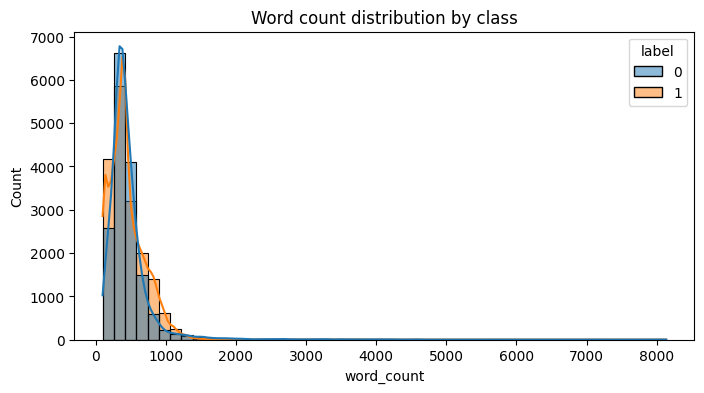

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="word_count", hue="label", bins=50, kde=True)
plt.title("Word count distribution by class")
plt.show()

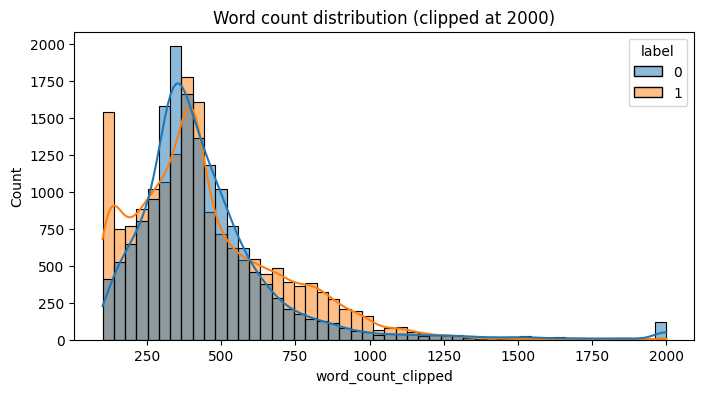

In [10]:
df["word_count_clipped"] = df["word_count"].clip(upper=2000)

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="word_count_clipped", hue="label", bins=50, kde=True)
plt.title("Word count distribution (clipped at 2000)")
plt.show()

In [11]:
df.groupby("label")[["text_length", "word_count"]].describe()

text_length                                                            \
            count         mean          std    min     25%     50%      75%   
label                                                                         
0         16104.0  2743.126987  2183.381429  510.0  1837.0  2326.0  3086.00   
1         17630.0  2765.625071  1585.539732  550.0  1664.0  2485.0  3596.75   

               word_count                                                \
           max      count        mean         std    min     25%    50%   
label                                                                     
0      51794.0    16104.0  457.565946  350.996209  100.0  310.75  391.0   
1      29781.0    17630.0  447.648327  257.994597  100.0  269.00  401.0   

                      
         75%     max  
label                 
0      516.0  8135.0  
1      581.0  5172.0

##### Text Length Analysis

The average article length is similar between reliable and unreliable news. However, unreliable articles exhibit noticeably higher variance and more extreme outliers, suggesting greater inconsistency in writing style and structure. This indicates that simple statistical features such as text length or word count alone are unlikely to provide strong predictive power

In [12]:
df["text_lc"] = df["text"].str.lower()

In [13]:
fake_texts = df[df["label"] == 0]["text_lc"].astype(str)
real_texts = df[df["label"] == 1]["text_lc"].astype(str)

vectorizer = CountVectorizer(stop_words="english", max_features=20, min_df=5)

,word,count
17,trump,67429
14,said,24728
11,people,21037
12,president,20632
6,just,16592
2,donald,15101
7,like,14229
1,clinton,13308
10,obama,13170
16,time,10626


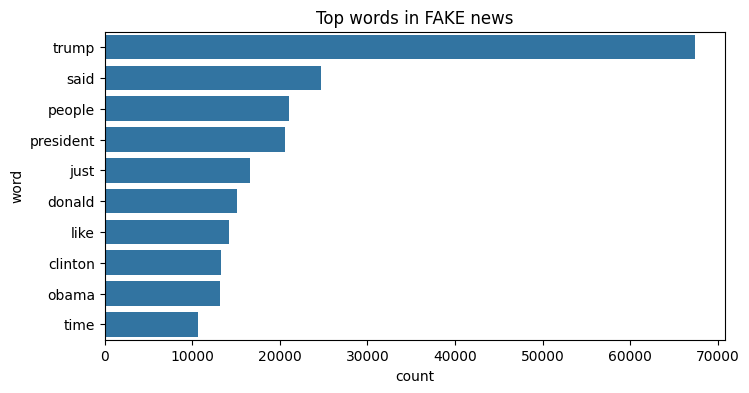

In [14]:
fake_counts = vectorizer.fit_transform(fake_texts)
fake_freq = np.array(fake_counts.sum(axis=0)).flatten()

fake_words = pd.DataFrame(
    {"word": vectorizer.get_feature_names_out(), "count": fake_freq}
).sort_values(by="count", ascending=False)

display(fake_words.head(10))
plt.figure(figsize=(8, 4))
sns.barplot(data=fake_words.head(10), x="count", y="word")
plt.title("Top words in FAKE news")
plt.show()

,word,count
12,said,92824
17,trump,51952
10,president,25601
14,state,20030
3,government,17962
15,states,15826
5,new,15478
11,republican,15425
4,house,15128
8,people,14675


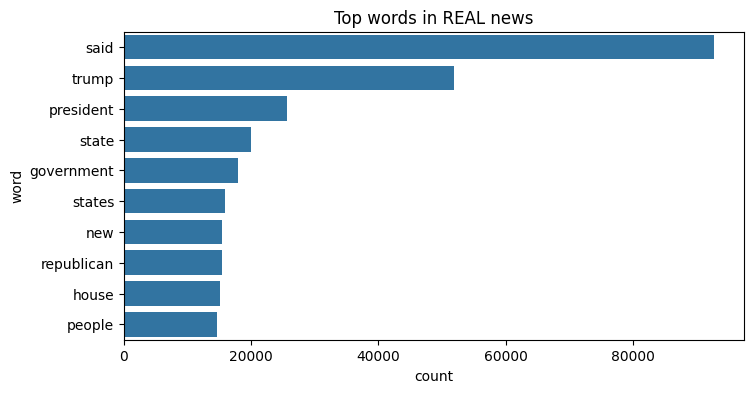

In [15]:
real_counts = vectorizer.fit_transform(real_texts)
real_freq = np.array(real_counts.sum(axis=0)).flatten()

real_words = pd.DataFrame(
    {"word": vectorizer.get_feature_names_out(), "count": real_freq}
).sort_values(by="count", ascending=False)

display(real_words.head(10))
plt.figure(figsize=(8, 4))
sns.barplot(data=real_words.head(10), x="count", y="word")
plt.title("Top words in REAL news")
plt.show()

In [16]:
text_0 = " ".join(df[df["label"] == 0]["text_lc"])
text_1 = " ".join(df[df["label"] == 1]["text_lc"])

wc0 = WordCloud(width=800, height=400, background_color="white").generate(text_0)

wc1 = WordCloud(width=800, height=400, background_color="white").generate(text_1)

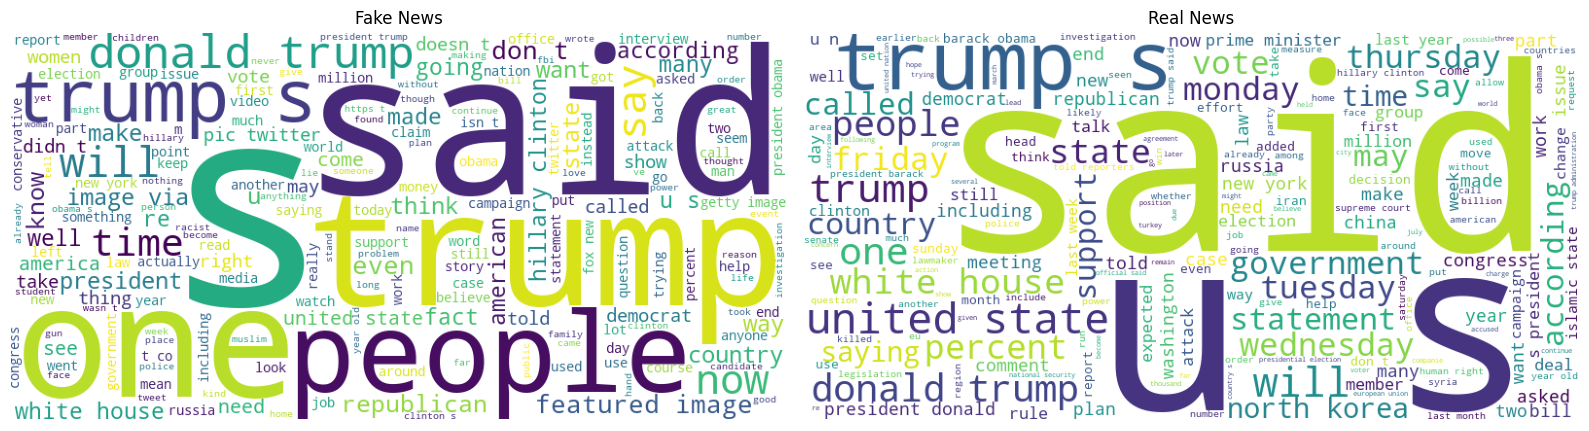

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc0)
axes[0].axis("off")
axes[0].set_title("Fake News")

axes[1].imshow(wc1)
axes[1].axis("off")
axes[1].set_title("Real News")

plt.tight_layout()
plt.show()

### Vocabulary Exploration

Reliable articles more frequently contain institutional and geopolitical terminology such as "government", "states", "republican", or "house", which is consistent with formal news reporting.

Unreliable articles contain a more personality-centered vocabulary, with a stronger focus on public figures and emotionally charged wording, including terms such as "trump", "clinton", "obama", and "like".

The overlap between classes is expected, as both datasets discuss similar real-world events and political topics. However, the differences in word distributions suggest that textual representations such as TF-IDF
may provide meaningful predictive signals for downstream machine learning models.

In [18]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, min_df=5)

X = tfidf.fit_transform(df["text"])
y = df["label"]

In [19]:
# from sklearn.manifold import TSNE
# tsne = TSNE(
#     n_components=2,
#     random_state=42,
#     perplexity=30,
#     init="random"
# )
# X_2d = tsne.fit_transform(X.toarray())

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

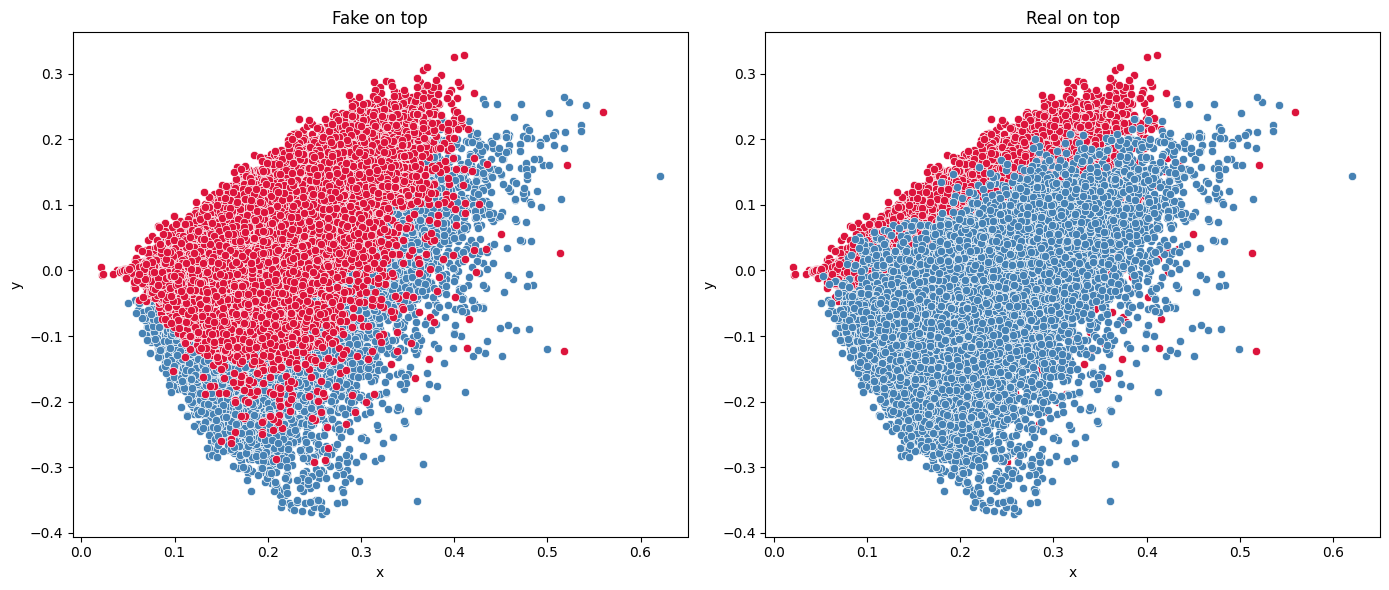

In [20]:
plot_df = pd.DataFrame(
    {"x": X_2d[:, 0], "y": X_2d[:, 1], "label": y.map({0: "Fake", 1: "Real"})}
)
data_real = plot_df[plot_df["label"] == "Real"]
data_fake = plot_df[plot_df["label"] == "Fake"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=data_real, x="x", y="y", color="steelblue", ax=axes[0])
sns.scatterplot(data=data_fake, x="x", y="y", color="crimson", ax=axes[0])
axes[0].set_title("Fake on top")

sns.scatterplot(data=data_fake, x="x", y="y", color="crimson", ax=axes[1])
sns.scatterplot(data=data_real, x="x", y="y", color="steelblue", ax=axes[1])
axes[1].set_title("Real on top")

plt.tight_layout()
plt.show()

### TF-IDF Embedding Projection

The resulting projection reveals partial separability between classes.
Although the classes overlap significantly, visible clustering patterns emerge,
indicating that textual content contains meaningful predictive signals.

In [21]:
for i in df["text"].tail(5).tolist():
    print(i)

NATO allies on Tuesday welcomed President Donald Trump s decision to commit more forces to Afghanistan, as part of a new U.S. strategy he said would require more troops and funding from America s partners. Having run for the White House last year on a pledge to withdraw swiftly from Afghanistan, Trump reversed course on Monday and promised a stepped-up military campaign against  Taliban insurgents, saying:  Our troops will fight to win .  U.S. officials said he had signed off on plans to send about 4,000 more U.S. troops to add to the roughly 8,400 now deployed in Afghanistan. But his speech did not define benchmarks for successfully ending the war that began with the U.S.-led invasion of Afghanistan in 2001, and which he acknowledged had required an   extraordinary sacrifice of blood and treasure .  We will ask our NATO allies and global partners to support our new strategy, with additional troops and funding increases in line with our own. We are confident they will,  Trump said. Tha